In [18]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import sharpy.cases.templates.flying_wings as wings
import sharpy.sharpy_main
import sharpy.utils.plotutils as pu

In [19]:
speed = 34
u_inf = speed #m/s
alpha_deg = 5
rho = 1.225

number_chordwise_panels = 16
number_spanwise_nodes = 32
wake_length_factor = 10

cases_folder = './cases/' # folder to store input files
output_folder = './output' # folder to save results
route_notebook_dir =  os.path.abspath('')

In [20]:
case_name = "Dynamic_Thicker2"
route_test_dir = os.path.abspath('')

length = 1.2
width = 0.06
height = 0.004
c_ref= 0.2
massperunit = 1.8
massweight = 0.1
simulation_time=2.0

pazy_altered = wings.PazyControlSurface(
    M = number_chordwise_panels,
    N = number_spanwise_nodes,
    Mstar_fact=wake_length_factor,
    u_inf=u_inf,
    alpha=alpha_deg,
    cs_deflection=[0,0],
    n_control_surfaces=2,
    rho=rho,
    tip_rod=False,
    b_ref=2.*length,
    main_chord=c_ref,
    pct_flap=0.2,
    aspect_ratio=2*length/c_ref,
    n_surfaces=2,
    route = cases_folder + '/' + case_name,
    case_name=case_name,
    physical_time = simulation_time,
)

In [21]:
def new_update_mass_stiff(self):
    import sharpy.utils.algebra as algebra

    #seeing our wing has roughly 2% of the area of the goland wing we have to scale the 
    #structural properties appropriately to achieve flutter, (as lift forces are proportional
    #to the wing area)
    E = 69e9  # Young's modulus in Pascals (Pa)
    G = 26e9  # Shear modulus in Pascals (Pa)
    rho = 2700

    # Cross-sectional properties
    A = width * height  # Area in m²
    Iy = (width * height**3) / 12  # Second moment of area about the y-axis (m⁴)
    Iz = (height * width**3) / 12  # Second moment of area about the z-axis (m⁴)
    print(Iy)
    print(Iz)
    J = 2*height**3*width/3  # Torsion constant approximation for rectangular section

    # Rigidity calculations
    EA = E * A
    GA = G * A
    GJ = G * J
    EIy = E * Iy
    EIz = E * Iz

    ea, ga = EA, GA
    gj = GJ
    eiy = EIy
    eiz = EIz
    base_stiffness = np.diag([ea, ga, ga, gj, eiy, eiz])
    self.stiffness = np.zeros((1, 6, 6))
    self.stiffness[0] = base_stiffness
    print(base_stiffness)
    
    m_unit = massperunit
    j_tors = (Iy+Iz)*rho
    print(Iy+Iz)
    print(j_tors)
    pos_cg_b = np.array([0., self.c_ref * (self.main_cg - self.main_ea), 0.])
    m_chi_cg = algebra.skew(m_unit * pos_cg_b)
    self.mass = np.zeros((1, 6, 6))
    self.mass[0, :, :] = np.diag([m_unit, m_unit, m_unit,
                                    j_tors, .1 * j_tors, .9 * j_tors])

    self.mass[0, :3, 3:] = m_chi_cg
    self.mass[0, 3:, :3] = -m_chi_cg

    self.elem_stiffness = np.zeros((self.num_elem_tot,), dtype=int)
    self.elem_mass = np.zeros((self.num_elem_tot,), dtype=int)

    n_lumped_mass = 2
    self.lumped_mass = np.zeros((n_lumped_mass))
    self.lumped_mass_position = np.zeros((n_lumped_mass, 3))
    self.lumped_mass_inertia = np.zeros((n_lumped_mass, 3, 3))
    self.lumped_mass_nodes = np.zeros((n_lumped_mass), dtype=int)

    #positive y is towards back
    self.lumped_mass[0] = massweight
    self.lumped_mass_position[0] = np.array([0, 0.5, 0])
    self.lumped_mass_nodes[0] = self.N//2
    self.lumped_mass_inertia[0, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

    self.lumped_mass[1] = massweight
    self.lumped_mass_position[1] = np.array([0, 0.5, 0])
    self.lumped_mass_nodes[1] = self.N//2+1
    self.lumped_mass_inertia[1, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

    self.main_ea = 0.33
    self.main_cg = 0.43

pazy_altered.update_mass_stiff = new_update_mass_stiff.__get__(pazy_altered, wings.PazyControlSurface) 

In [22]:
pazy_altered.clean_test_files()
pazy_altered.update_derived_params()
pazy_altered.set_default_config_dict()

pazy_altered.generate_aero_file()
pazy_altered.generate_fem_file()

3.2e-10
7.2e-08
[[1.656e+07 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 6.240e+06 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 6.240e+06 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 6.656e+01 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 2.208e+01 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 4.968e+03]]
7.232e-08
0.000195264


In [23]:
rom_settings = dict()
rom_settings['algorithm'] = 'mimo_rational_arnoldi'  # reduction algorithm
rom_settings['r'] = 6  # Krylov subspace order
frequency_continuous_k = np.array([0.])  # Interpolation point in the complex plane with reduced frequency units
frequency_continuous_w = 2 * u_inf * frequency_continuous_k / c_ref
rom_settings['frequency'] = frequency_continuous_w

pazy_altered.set_default_config_dict()
pazy_altered.config['SHARPy'] = {
    'flow':
    [
        'BeamLoader',
        'AerogridLoader',
        'StaticCoupled',
        'AerogridPlot',
        'BeamPlot',
        'DynamicCoupled',
    ],
    'case': pazy_altered.case_name, 'route' : pazy_altered.route,
    'write_screen': 'on', 'write_log': 'on',
    'save_settings' : 'on',
    'log_folder': output_folder + '/',
    'log_file': pazy_altered.case_name+'.log'
    }

pazy_altered.config['BeamLoader'] = {
    'unsteady': 'off',
    'orientation': pazy_altered.quat
}

pazy_altered.config['AerogridLoader'] = {
    'unsteady': 'on',
    'aligned_grid': 'on',
    'mstar': wake_length_factor*pazy_altered.M,
    'wake_shape_generator': 'StraightWake',
    'wake_shape_generator_input': {
        'u_inf':pazy_altered.u_inf,
        'u_inf_direction': [1., 0., 0.],
        'dt': pazy_altered.dt,
    },
}

pazy_altered.config['StaticCoupled'] = {
        'print_info': 'on',
        'max_iter': 200,
        'n_load_steps': 5,
        'tolerance': 1e-5,
        'relaxation_factor': 0.1,
        'aero_solver': 'StaticUvlm',
        'aero_solver_settings': {
            'rho': pazy_altered.rho,
            'print_info': 'off',
            'horseshoe': 'on',
            'num_cores': 4,
            'n_rollup': 0,
            'velocity_field_generator': 'SteadyVelocityField',
            'velocity_field_input': {
                'u_inf': pazy_altered.u_inf,
                'u_inf_direction': pazy_altered.u_inf_direction},
            'vortex_radius': 1e-9},
        'structural_solver': 'NonLinearStatic',
        'structural_solver_settings': {'print_info': 'off',
                                   'max_iterations': 200,
                                   'num_load_steps': 5,
                                   'delta_curved': 1e-6,
                                   'min_delta': 1e-8,
                                   'gravity': True,
                                   'gravity': 9.81},
    }
pazy_altered.config['AerogridPlot'] = {'include_rbm': 'off',
                                               'include_applied_forces': 'on',
                                               'minus_m_star': 0}

pazy_altered.config['BeamPlot'] = {'include_rbm': 'off',
                                           'include_applied_forces': 'on'}
    
pazy_altered.config['WriteVariablesTime'] = {'structure_variables': ['pos'],
                                                     'structure_nodes': list(range(0, pazy_altered.num_node_surf)),
                                                     'cleanup_old_solution': 'on',}

pazy_altered.config['DynamicCoupled'] = {'print_info': 'on',
                                  'structural_substeps': 10,
                                  'dynamic_relaxation': 'on',
                                  'cleanup_previous_solution': 'on',
                                  'structural_solver': 'NonLinearDynamicPrescribedStep',
                                  'structural_solver_settings':  {'print_info': 'off',
                                                                'max_iterations': 950,
                                                                'delta_curved': 1e-1,
                                                                'min_delta': 1e-6,
                                                                'newmark_damp': 0.5e-4,
                                                                'gravity': True,
                                                                'gravity': 9.81,
                                                                'num_steps': pazy_altered.n_tstep,
                                                                'dt':pazy_altered.dt,
                                                                },
                                  'aero_solver': 'StepUvlm',
                                  'aero_solver_settings':  {'print_info': 'on',
                                                            'num_cores': 4,
                                                            'convection_scheme': 2,
                                                            'velocity_field_generator': 'SteadyVelocityField',
                                                            'velocity_field_input': {'u_inf': pazy_altered.u_inf,
                                                                                    'u_inf_direction': [1., 0., 0.]},
                                                            'rho': pazy_altered.rho,
                                                            'n_time_steps': pazy_altered.n_tstep,
                                                            'vortex_radius': 1e-9,
                                                            'dt': pazy_altered.dt,
                                                            'gamma_dot_filtering': 3},
                                  'fsi_substeps': 200,
                                  'fsi_tolerance': 1e-6,
                                  'relaxation_factor': pazy_altered.relaxation_factor,
                                  'minimum_steps': 1,
                                  'relaxation_steps': 150,
                                  'final_relaxation_factor': 0.0,
                                  'n_time_steps': pazy_altered.n_tstep,
                                  'dt': pazy_altered.dt,
                                  'include_unsteady_force_contribution':  True,
                                  'postprocessors': ['WriteVariablesTime', 'BeamPlot', 'AerogridPlot'],
                                  'postprocessors_settings': {'BeamPlot': {'include_rbm': 'on',
                                                                           'include_applied_forces': 'on'},
                                                              'StallCheck': {},
                                                              'AerogridPlot': {
                                                                  'u_inf': pazy_altered.u_inf,
                                                                  'include_rbm': 'on',
                                                                  'include_applied_forces': 'on',
                                                                  'minus_m_star': 0},
                                                              'WriteVariablesTime': {
                                                                  'structure_variables': ['pos', 'psi'],
                                                                  'structure_nodes': [pazy_altered.num_node_surf - 1,
                                                                                      pazy_altered.num_node_surf,
                                                                                      pazy_altered.num_node_surf + 1],
                                                                    },
                                                                    },
                                    'network_settings': {},
                                    }

pazy_altered.config['PickleData'] = {}
pazy_altered.config['LinearAssembler'] = {'linear_system': 'LinearAeroelastic',
                                    'inout_coordinates': 'nodes', 
                                    # 'recover_accelerations': True,           
                                'linear_system_settings': {
                                    'beam_settings': {'modal_projection': True,
                                                        'inout_coords': 'modes',
                                                        'discrete_time': True,
                                                        'newmark_damp': 0.5e-4,
                                                        'discr_method': 'newmark',
                                                        'dt': pazy_altered.dt,
                                                        'proj_modes': 'undamped',
                                                        'num_modes': 20,
                                                        'print_info': 'on',
                                                        'gravity': True,
                                                        'remove_dofs': []},
                                    'aero_settings': {'dt': pazy_altered.dt,
                                                        'integr_order': 2,
                                                        'density': pazy_altered.rho,
                                                        'remove_predictor': True,
                                                        'use_sparse': 'off',
                                                        'gust_assembler':  'LeadingEdge',
                                                        'ScalingDict': {'length':1, 'speed': 1, 'density': 1},
                                                        },
                                    'track_body': False,
                                    'use_euler': False,
                                    }}
pazy_altered.config['Modal'] = {'print_info': True,
                            'use_undamped_modes': True,
                            'NumLambda': 20,
                            'rigid_body_modes': False, 
                            'write_modes_vtk': False,
                            'print_matrices': False,
                            'continuous_eigenvalues': 'off',
                            'dt': pazy_altered.dt,
                            'plot_eigenvalues': False,
                            }
pazy_altered.config['SaveData']['save_linear'] = True

pazy_altered.config.write()

In [7]:
sharpy.sharpy_main.main(['', pazy_altered.route + pazy_altered.case_name + '.sharpy'])

--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.
    License available at https://github.com/imperialcollegelondon/sharpy
Running SHARPy from /home/password/sharpy/sharpy
SHARPy being run is in /home/password/.local/lib/python3.10/site-packages
SHARPy output folder set
	./output//Dynamic_Thicker2/
Generatin

fatal: not a git repository (or any of the parent directories): .git


|  0  |  0  |  0.00000   | -2.2341  |  0.0000  | 30.0233  | -0.0000  |  0.4050  | -0.0000  |
|  1  |  0  |  -4.84688  | -2.2741  |  0.0000  | 30.3090  | -0.0000  |  0.4085  | -0.0000  |
|  2  |  0  |  -5.74951  | -2.2790  |  0.0000  | 30.3439  | -0.0000  |  0.4089  | -0.0000  |
|  0  |  1  |  0.00000   | -4.4941  |  0.0000  | 59.5555  | -0.0000  |  0.5960  | -0.0000  |
|  1  |  1  |  -4.23364  | -4.4528  |  0.0000  | 59.3488  | -0.0001  |  0.6045  | -0.0000  |
|  2  |  1  |  -5.65212  | -4.4522  |  0.0001  | 59.3503  | -0.0001  |  0.6050  | -0.0000  |
|  0  |  2  |  0.00000   | -6.6079  |  0.0001  | 86.2590  | -0.0001  |  0.5799  | -0.0000  |
|  1  |  2  |  -3.44271  | -6.3801  |  0.0002  | 85.0837  | -0.0002  |  0.6244  | -0.0000  |
|  2  |  2  |  -5.19285  | -6.3857  |  0.0002  | 85.1215  | -0.0002  |  0.6239  | -0.0000  |
|  0  |  3  |  0.00000   | -8.4523  |  0.0004  | 108.7816 | -0.0002  |  0.4247  | -0.0000  |
|  1  |  3  |  -3.03133  | -7.9806  |  0.0007  | 106.6662 | -0.0005  |

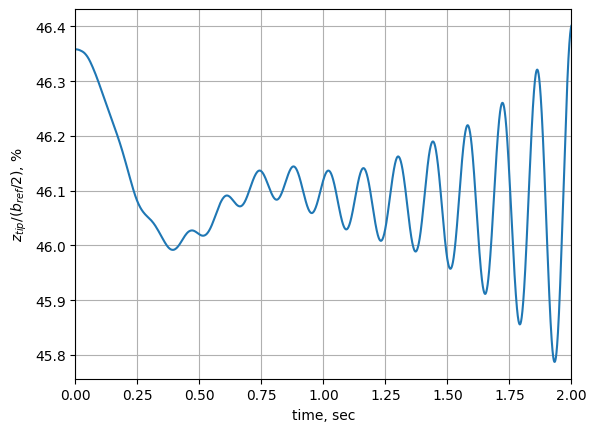

In [24]:
def get_resulting_vertical_tip_displacement(output_folder, model):    
    file_results = os.path.join(output_folder, 
                                 model.case_name, 
                                 'WriteVariablesTime',
                                 'struct_pos_node{}.dat'.format(model.num_node_surf))
    vertical_tip_displacement = np.loadtxt(file_results)[:,-1]
    
                                             
    return vertical_tip_displacement


tip_displacement_open_loop = get_resulting_vertical_tip_displacement(output_folder, 
                                                                     pazy_altered)


time_array = np.arange(0, len(tip_displacement_open_loop) * pazy_altered.dt, pazy_altered.dt)
normalised_tip_displacement = tip_displacement_open_loop/ (0.5*pazy_altered.b_ref) #normalise by half wing span
normalised_tip_displacement *=100# cconvert to percentnvert to percent
plt.plot(time_array, normalised_tip_displacement)
plt.xlabel('time, sec')
plt.ylabel('$z_{tip}/(b_{ref}/2)$, %')
plt.xlim([0., simulation_time])
plt.grid()
plt.show()

In [25]:
case_name = 'control2_ROM'

flow = ['BeamLoader',
        'AerogridLoader',
        'StaticCoupled',
        'DynamicCoupled',
        'Modal',
        'LinearAssembler',
        'SaveData',
        ]

simulation_time_ROM = pazy_altered.dt # only one timestep has to be performed
gust = False

use_rom = True
rom_settings = {
    'use': use_rom,
    'rom_method': 'Krylov',
    'rom_method_settings': {'Krylov': {
                                        'algorithm': 'mimo_rational_arnoldi',
                                        'r': 4,
                                        'frequency': np.array([0]),
                                        'single_side': 'observability',
                                        },
                           }
                }

num_modes = 20

unsteady_force_contribution = False
remove_gust_input_in_statespace = False

In [26]:
pazy_model_ROM = wings.PazyControlSurface(M=number_chordwise_panels,
                                      N=number_spanwise_nodes,
                                      Mstar_fact=wake_length_factor,
                                      u_inf=u_inf,
                                      alpha=alpha_deg,
                                      cs_deflection=[0,0],
                                      n_control_surfaces=2,
                                      rho=rho,
                                      tip_rod = False,
                                      b_ref=2. * length,
                                      main_chord= c_ref,
                                      pct_flap=0.2375, #285mm/1200mm
                                      aspect_ratio=(2. * length) / c_ref,
                                      sweep=0,
                                      cs_type=0, #flap?
                                      n_surfaces=2,
                                      route=cases_folder + '/' + case_name,
                                      case_name=case_name,
                                      physical_time=simulation_time_ROM,)

pazy_model_ROM.update_mass_stiff = new_update_mass_stiff.__get__(pazy_model_ROM, wings.PazyControlSurface) 
pazy_model_ROM.clean_test_files()
pazy_model_ROM.update_derived_params()
pazy_model_ROM.set_default_config_dict()

pazy_model_ROM.generate_aero_file()
pazy_model_ROM.generate_fem_file()

3.2e-10
7.2e-08
[[1.656e+07 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 6.240e+06 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 6.240e+06 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 6.656e+01 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 2.208e+01 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 4.968e+03]]
7.232e-08
0.000195264


In [27]:
pazy_model_ROM.set_default_config_dict()
pazy_model_ROM.config['SHARPy'] = {
    'flow':
    [
        'BeamLoader',
        'AerogridLoader',
        'StaticCoupled',
        'AerogridPlot',
        'BeamPlot',
        'DynamicCoupled',
    ],
    'case': pazy_model_ROM.case_name, 'route' : pazy_model_ROM.route,
    'write_screen': 'on', 'write_log': 'on',
    'save_settings' : 'on',
    'log_folder': output_folder + '/',
    'log_file': pazy_model_ROM.case_name+'.log'
    }

pazy_model_ROM.config['BeamLoader'] = {
    'unsteady': 'off',
    'orientation': pazy_model_ROM.quat
}

pazy_model_ROM.config['AerogridLoader'] = {
    'unsteady': 'on',
    'aligned_grid': 'on',
    'mstar': wake_length_factor*pazy_model_ROM.M,
    'wake_shape_generator': 'StraightWake',
    'wake_shape_generator_input': {
        'u_inf':pazy_model_ROM.u_inf,
        'u_inf_direction': [1., 0., 0.],
        'dt': pazy_model_ROM.dt,
    },
}

pazy_model_ROM.config['StaticCoupled'] = {
        'print_info': 'on',
        'max_iter': 200,
        'n_load_steps': 5,
        'tolerance': 1e-5,
        'relaxation_factor': 0.1,
        'aero_solver': 'StaticUvlm',
        'aero_solver_settings': {
            'rho': pazy_model_ROM.rho,
            'print_info': 'off',
            'horseshoe': 'on',
            'num_cores': 4,
            'n_rollup': 0,
            'velocity_field_generator': 'SteadyVelocityField',
            'velocity_field_input': {
                'u_inf': pazy_model_ROM.u_inf,
                'u_inf_direction': pazy_model_ROM.u_inf_direction},
            'vortex_radius': 1e-9},
        'structural_solver': 'NonLinearStatic',
        'structural_solver_settings': {'print_info': 'off',
                                   'max_iterations': 200,
                                   'num_load_steps': 5,
                                   'delta_curved': 1e-6,
                                   'min_delta': 1e-8,
                                   'gravity': True,
                                   'gravity': 9.81},
    }
pazy_model_ROM.config['AerogridPlot'] = {'include_rbm': 'off',
                                               'include_applied_forces': 'on',
                                               'minus_m_star': 0}

pazy_model_ROM.config['BeamPlot'] = {'include_rbm': 'off',
                                           'include_applied_forces': 'on'}
    
pazy_model_ROM.config['WriteVariablesTime'] = {'structure_variables': ['pos'],
                                                     'structure_nodes': list(range(0, pazy_model_ROM.num_node_surf)),
                                                     'cleanup_old_solution': 'on',}

pazy_model_ROM.config['DynamicCoupled'] = {'print_info': 'on',
                                  'structural_substeps': 10,
                                  'dynamic_relaxation': 'on',
                                  'cleanup_previous_solution': 'on',
                                  'structural_solver': 'NonLinearDynamicPrescribedStep',
                                  'structural_solver_settings':  {'print_info': 'off',
                                                                'max_iterations': 950,
                                                                'delta_curved': 1e-1,
                                                                'min_delta': 1e-6,
                                                                'newmark_damp': 0.5e-4,
                                                                'gravity': True,
                                                                'gravity': 9.81,
                                                                'num_steps': pazy_model_ROM.n_tstep,
                                                                'dt':pazy_model_ROM.dt,
                                                                },
                                  'aero_solver': 'StepUvlm',
                                  'aero_solver_settings':  {'print_info': 'on',
                                                            'num_cores': 4,
                                                            'convection_scheme': 2,
                                                            'velocity_field_generator': 'SteadyVelocityField',
                                                            'velocity_field_input': {'u_inf': pazy_model_ROM.u_inf,
                                                                                    'u_inf_direction': [1., 0., 0.]},
                                                            'rho': pazy_model_ROM.rho,
                                                            'n_time_steps': pazy_model_ROM.n_tstep,
                                                            'vortex_radius': 1e-9,
                                                            'dt': pazy_model_ROM.dt,
                                                            'gamma_dot_filtering': 3},
                                  'fsi_substeps': 200,
                                  'fsi_tolerance': 1e-6,
                                  'relaxation_factor': pazy_model_ROM.relaxation_factor,
                                  'minimum_steps': 1,
                                  'relaxation_steps': 150,
                                  'final_relaxation_factor': 0.0,
                                  'n_time_steps': pazy_model_ROM.n_tstep,
                                  'dt': pazy_model_ROM.dt,
                                  'include_unsteady_force_contribution':  True,
                                  'postprocessors': ['WriteVariablesTime', 'BeamPlot', 'AerogridPlot'],
                                  'postprocessors_settings': {'BeamPlot': {'include_rbm': 'on',
                                                                           'include_applied_forces': 'on'},
                                                              'StallCheck': {},
                                                              'AerogridPlot': {
                                                                  'u_inf': pazy_model_ROM.u_inf,
                                                                  'include_rbm': 'on',
                                                                  'include_applied_forces': 'on',
                                                                  'minus_m_star': 0},
                                                              'WriteVariablesTime': {
                                                                  'structure_variables': ['pos', 'psi'],
                                                                  'structure_nodes': [pazy_model_ROM.num_node_surf - 1,
                                                                                      pazy_model_ROM.num_node_surf,
                                                                                      pazy_model_ROM.num_node_surf + 1],
                                                                    },
                                                                    },
                                    'network_settings': {},
                                    }

pazy_model_ROM.config['PickleData'] = {}
pazy_model_ROM.config['LinearAssembler'] = {'linear_system': 'LinearAeroelastic',
                                    'inout_coordinates': 'nodes', 
                                    # 'recover_accelerations': True,           
                                'linear_system_settings': {
                                    'beam_settings': {'modal_projection': True,
                                                        'inout_coords': 'modes',
                                                        'discrete_time': True,
                                                        'newmark_damp': 0.5e-4,
                                                        'discr_method': 'newmark',
                                                        'dt': pazy_model_ROM.dt,
                                                        'proj_modes': 'undamped',
                                                        'num_modes': 20,
                                                        'print_info': 'on',
                                                        'gravity': True,
                                                        'remove_dofs': []},
                                    'aero_settings': {'dt': pazy_model_ROM.dt,
                                                        'integr_order': 2,
                                                        'density': pazy_model_ROM.rho,
                                                        'remove_predictor': True,
                                                        'use_sparse': 'off',
                                                        'gust_assembler':  'LeadingEdge',
                                                        'ScalingDict': {'length':1, 'speed': 1, 'density': 1},
                                                        },
                                    'track_body': False,
                                    'use_euler': False,
                                    }}
pazy_model_ROM.config['Modal'] = {'print_info': True,
                            'use_undamped_modes': True,
                            'NumLambda': 20,
                            'rigid_body_modes': False, 
                            'write_modes_vtk': False,
                            'print_matrices': False,
                            'continuous_eigenvalues': 'off',
                            'dt': pazy_model_ROM.dt,
                            'plot_eigenvalues': False,
                            }
pazy_model_ROM.config['SaveData']['save_linear'] = True

pazy_model_ROM.config.write()

In [28]:
sharpy.sharpy_main.main(['', pazy_model_ROM.route + pazy_model_ROM.case_name + '.sharpy'])

--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.
    License available at https://github.com/imperialcollegelondon/sharpy
Running SHARPy from /home/user/sharpy/sharpy
SHARPy being run is in /home/user/.local/lib/python3.10/site-packages
SHARPy output folder set
	./output//control2_ROM/
Generating an instanc

fatal: not a git repository (or any of the parent directories): .git


|  0  |  0  |  0.00000   | -2.2341  |  0.0000  | 30.0233  | -0.0000  |  0.4050  | -0.0000  |
|  1  |  0  |  -4.84688  | -2.2741  |  0.0000  | 30.3090  | -0.0000  |  0.4085  | -0.0000  |
|  2  |  0  |  -5.74951  | -2.2790  |  0.0000  | 30.3439  | -0.0000  |  0.4089  | -0.0000  |
|  0  |  1  |  0.00000   | -4.4941  |  0.0000  | 59.5555  | -0.0000  |  0.5960  | -0.0000  |
|  1  |  1  |  -4.23364  | -4.4528  |  0.0000  | 59.3488  | -0.0001  |  0.6045  | -0.0000  |
|  2  |  1  |  -5.65212  | -4.4522  |  0.0001  | 59.3503  | -0.0001  |  0.6050  | -0.0000  |
|  0  |  2  |  0.00000   | -6.6079  |  0.0001  | 86.2590  | -0.0001  |  0.5799  | -0.0000  |
|  1  |  2  |  -3.44271  | -6.3801  |  0.0002  | 85.0837  | -0.0002  |  0.6244  | -0.0000  |
|  2  |  2  |  -5.19285  | -6.3857  |  0.0002  | 85.1215  | -0.0002  |  0.6239  | -0.0000  |
|  0  |  3  |  0.00000   | -8.4523  |  0.0004  | 108.7816 | -0.0002  |  0.4247  | -0.0000  |
|  1  |  3  |  -3.03133  | -7.9806  |  0.0007  | 106.6662 | -0.0005  |

In [29]:
folder_linear_results =os.path.join(output_folder, pazy_model_ROM.case_name,'linear_results')
if not os.path.exists(folder_linear_results):
    os.makedirs(folder_linear_results)

import scipy.io

parameter_matlab = {'num_aero_states': 80, # see log file
                    'num_modes': 20,  # see log file
                     'u_inf': float(pazy_model_ROM.u_inf),
                    'simulation_time': simulation_time,
                    'gust_length': float(10),
                    'gust_intensity': float(0),
                    'num_control_surfaces': 2,
                    'n_nodes': number_spanwise_nodes,
                    'control_input_start': 193 + 1, # see log file and + 1 for matlab indices
                    'gust_input_start': 192 + 1 , # see log file and + 1 for matlab indices
                   }

scipy.io.savemat(os.path.join(folder_linear_results, 'simulation_parameters.mat'), parameter_matlab)

In [30]:
import matlab.engine
eng = matlab.engine.start_matlab()
eng.control_design_script(route_notebook_dir)

Simulate linear open-loop gust response.Found algebraic loop that contains: 
PID_linear_model/IC
PID_linear_model/controller_on_off
PID_linear_model/Discrete Derivative/TSamp
PID_linear_model/Discrete Derivative/Diff
PID_linear_model/Gain
PID_linear_model/Vector Concatenate
PID_linear_model/Discrete State-Space
PID_linear_model/PID Controller/D Gain/Internal Parameters/Derivative Gain
PID_linear_model/PID Controller/Filter/Differentiator/Tsamp/Internal Ts/Tsamp
PID_linear_model/PID Controller/Filter/Differentiator/Diff
PID_linear_model/PID Controller/Parallel P Gain/Internal Parameters/Proportional Gain
PID_linear_model/PID Controller/Sum/Sum_PID/Sum (algebraic variable)
Simulate linear closed-loop gust response with P=5.Found algebraic loop that contains: 
PID_linear_model/IC
PID_linear_model/controller_on_off
PID_linear_model/Discrete Derivative/TSamp
PID_linear_model/Discrete Derivative/Diff
PID_linear_model/Gain
PID_linear_model/Vector Concatenate
PID_linear_model/Discrete State-Sp

True

In [31]:
# Clean Up Simulink Files
import shutil
folder_path = os.path.join(route_notebook_dir, 'slprj')
if os.path.exists(folder_path):
    shutil.rmtree(folder_path)

file_path = os.path.join(route_notebook_dir,  'PID_linear_model.slxc')
if os.path.exists(file_path):
    os.remove(file_path)

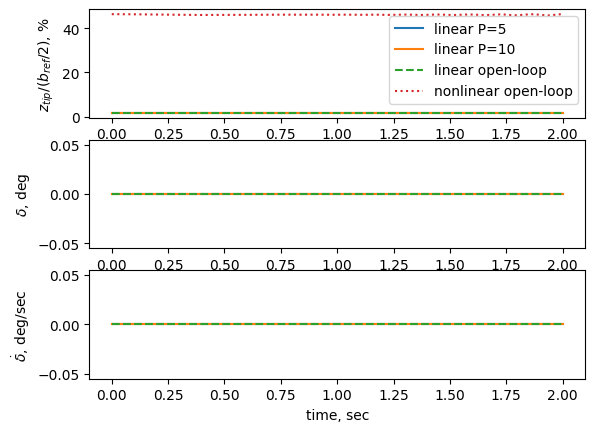

In [32]:
# Load linear results
tip_deflection_linear = np.loadtxt(folder_linear_results + '/tip_deflection.txt', delimiter = ',')
time_array_linear = np.loadtxt(folder_linear_results + '/time_array_linear.txt', delimiter = ',')
normalised_tip_deflection_linear = tip_deflection_linear / (0.5 *pazy_model_ROM.b_ref) * 100
control_surface_deflection_deg = np.loadtxt(folder_linear_results + '/deflection.txt', delimiter = ',')
control_surface_deflection_rate_deg = np.loadtxt(folder_linear_results + '/deflection_rate.txt', delimiter = ',')

# Plot Data
fig, axs = plt.subplots(3, 1)
list_linestyles = ['-', '-', '--', ':']
list_labels = ['linear P=5', 'linear P=10', 'linear open-loop', 'nonlinear open-loop']
for i in range(3):
    axs[0].plot(time_array_linear, normalised_tip_deflection_linear[:,i], list_linestyles[i], label=list_labels[i])

axs[0].plot(time_array, normalised_tip_displacement, list_linestyles[-1], label=list_labels[-1])
axs[0].legend(loc ='upper right')
axs[0].set(ylabel='$z_{tip}/(b_{ref}/2)$, %')

for i in range(3):
    axs[1].plot(time_array_linear, control_surface_deflection_deg[:,i], list_linestyles[i])

axs[1].set(ylabel='$\delta$, deg')
for i in range(3):
    axs[2].plot(time_array_linear, control_surface_deflection_rate_deg[:,i], list_linestyles[i])

axs[2].set(ylabel='$\dot{\delta}$, deg/sec')
for ax in axs.flat:
    ax.set(xlabel='time, sec')

In [ ]:
case_name = 'pazy_control_closed'
gust = True
flow = ['BeamLoader',
        'AerogridLoader',
        'StaticCoupled',
        'DynamicCoupled',
        ]
initial_cs_deflection = [0, 0]
cs_type = 2

pazy_model_closed = wings.PazyControlSurface(M=number_chordwise_panels,
                                      N=number_spanwise_nodes,
                                      Mstar_fact=wake_length_factor,
                                      u_inf=u_inf,
                                      alpha=alpha_deg,
                                      cs_deflection=initial_cs_deflection,
                                      rho=rho,
                                      n_surfaces=2,
                                      route=cases_folder + '/' + case_name,
                                      case_name=case_name,
                                      physical_time=simulation_time,
                                      cs_type=cs_type)
pazy_model_closed.clean_test_files()
pazy_model_closed.update_derived_params()
pazy_model_closed.generate_aero_file()
pazy_model_closed.generate_fem_file()

#  Network settings for nonlinear in closed-loop simulations
server_ip_addr = '127.0.0.1' # SHARPy
client_ip_addr = '127.0.0.1' # controller
port_in_network = 64017
port_out_network_server = 59017
port_out_network_client = 59007
num_sensors = 1
network_settings = {'variables_filename': route_notebook_dir + '/pazy_network_info.yml',
                                        'send_output_to_all_clients': False,
                                        'byte_ordering': 'little',
                                        'log_name': output_folder +'/'+ case_name + '/sharpy_network.log',
                                        'file_log_level': 'debug',
                                        'console_log_level': 'error',
                                        'input_network_settings': {'address': server_ip_addr,
                                                                        'port': port_in_network,
                                                                        },
                                        'output_network_settings': {'send_on_demand': False,
                                                                        'port': port_out_network_server,
                                                                        'address':server_ip_addr,
                                                                        'destination_address': [client_ip_addr],
                                                                        'destination_ports': [port_out_network_client],
                                                                }
                                                }

pazy_model_closed.set_default_config_dict()
pazy_model_closed.config['SHARPy'] = {
    'flow':
    [
        'BeamLoader',
        'AerogridLoader',
        'StaticCoupled',
        'AerogridPlot',
        'BeamPlot',
        'DynamicCoupled',
    ],
    'case': pazy_model_closed.case_name, 'route' : pazy_model_closed.route,
    'write_screen': 'on', 'write_log': 'on',
    'save_settings' : 'on',
    'log_folder': output_folder + '/',
    'log_file': pazy_model_closed.case_name+'.log'
    }

pazy_model_closed.config['BeamLoader'] = {
    'unsteady': 'off',
    'orientation': pazy_model_closed.quat
}

pazy_model_closed.config['AerogridLoader'] = {
    'unsteady': 'on',
    'aligned_grid': 'on',
    'mstar': wake_length_factor*pazy_model_closed.M,
    'wake_shape_generator': 'StraightWake',
    'wake_shape_generator_input': {
        'u_inf':pazy_model_closed.u_inf,
        'u_inf_direction': [1., 0., 0.],
        'dt': pazy_model_closed.dt,
    },
}

pazy_model_closed.config['StaticCoupled'] = {
        'print_info': 'on',
        'max_iter': 200,
        'n_load_steps': 5,
        'tolerance': 1e-5,
        'relaxation_factor': 0.1,
        'aero_solver': 'StaticUvlm',
        'aero_solver_settings': {
            'rho': pazy_model_closed.rho,
            'print_info': 'off',
            'horseshoe': 'on',
            'num_cores': 4,
            'n_rollup': 0,
            'velocity_field_generator': 'SteadyVelocityField',
            'velocity_field_input': {
                'u_inf': pazy_model_closed.u_inf,
                'u_inf_direction': pazy_model_closed.u_inf_direction},
            'vortex_radius': 1e-9},
        'structural_solver': 'NonLinearStatic',
        'structural_solver_settings': {'print_info': 'off',
                                   'max_iterations': 200,
                                   'num_load_steps': 5,
                                   'delta_curved': 1e-6,
                                   'min_delta': 1e-8,
                                   'gravity': True,
                                   'gravity': 9.81},
    }
pazy_model_closed.config['AerogridPlot'] = {'include_rbm': 'off',
                                               'include_applied_forces': 'on',
                                               'minus_m_star': 0}

pazy_model_closed.config['BeamPlot'] = {'include_rbm': 'off',
                                           'include_applied_forces': 'on'}
    
pazy_model_closed.config['WriteVariablesTime'] = {'structure_variables': ['pos'],
                                                     'structure_nodes': list(range(0, pazy_model_closed.num_node_surf)),
                                                     'cleanup_old_solution': 'on',}

pazy_model_closed.config['DynamicCoupled'] = {'print_info': 'on',
                                  'structural_substeps': 10,
                                  'dynamic_relaxation': 'on',
                                  'cleanup_previous_solution': 'on',
                                  'structural_solver': 'NonLinearDynamicPrescribedStep',
                                  'structural_solver_settings':  {'print_info': 'off',
                                                                'max_iterations': 950,
                                                                'delta_curved': 1e-1,
                                                                'min_delta': 1e-6,
                                                                'newmark_damp': 0.5e-4,
                                                                'gravity': True,
                                                                'gravity': 9.81,
                                                                'num_steps': pazy_model_closed.n_tstep,
                                                                'dt':pazy_model_closed.dt,
                                                                },
                                  'aero_solver': 'StepUvlm',
                                  'aero_solver_settings':  {'print_info': 'on',
                                                            'num_cores': 4,
                                                            'convection_scheme': 2,
                                                            'velocity_field_generator': 'SteadyVelocityField',
                                                            'velocity_field_input': {'u_inf': pazy_model_closed.u_inf,
                                                                                    'u_inf_direction': [1., 0., 0.]},
                                                            'rho': pazy_model_closed.rho,
                                                            'n_time_steps': pazy_model_closed.n_tstep,
                                                            'vortex_radius': 1e-9,
                                                            'dt': pazy_model_closed.dt,
                                                            'gamma_dot_filtering': 3},
                                  'fsi_substeps': 200,
                                  'fsi_tolerance': 1e-6,
                                  'relaxation_factor': pazy_model_closed.relaxation_factor,
                                  'minimum_steps': 1,
                                  'relaxation_steps': 150,
                                  'final_relaxation_factor': 0.0,
                                  'n_time_steps': pazy_model_closed.n_tstep,
                                  'dt': pazy_model_closed.dt,
                                  'include_unsteady_force_contribution':  True,
                                  'postprocessors': ['WriteVariablesTime', 'BeamPlot', 'AerogridPlot'],
                                  'postprocessors_settings': {'BeamPlot': {'include_rbm': 'on',
                                                                           'include_applied_forces': 'on'},
                                                              'StallCheck': {},
                                                              'AerogridPlot': {
                                                                  'u_inf': pazy_model_closed.u_inf,
                                                                  'include_rbm': 'on',
                                                                  'include_applied_forces': 'on',
                                                                  'minus_m_star': 0},
                                                              'WriteVariablesTime': {
                                                                  'structure_variables': ['pos', 'psi'],
                                                                  'structure_nodes': [pazy_model_closed.num_node_surf - 1,
                                                                                      pazy_model_closed.num_node_surf,
                                                                                      pazy_model_closed.num_node_surf + 1],
                                                                    },
                                                                    },
                                    'network_settings': {},
                                    }

pazy_model_closed.config['PickleData'] = {}
pazy_model_closed.config['LinearAssembler'] = {'linear_system': 'LinearAeroelastic',
                                    'inout_coordinates': 'nodes', 
                                    # 'recover_accelerations': True,           
                                'linear_system_settings': {
                                    'beam_settings': {'modal_projection': True,
                                                        'inout_coords': 'modes',
                                                        'discrete_time': True,
                                                        'newmark_damp': 0.5e-4,
                                                        'discr_method': 'newmark',
                                                        'dt': pazy_model_closed.dt,
                                                        'proj_modes': 'undamped',
                                                        'num_modes': 20,
                                                        'print_info': 'on',
                                                        'gravity': True,
                                                        'remove_dofs': []},
                                    'aero_settings': {'dt': pazy_model_closed.dt,
                                                        'integr_order': 2,
                                                        'density': pazy_model_closed.rho,
                                                        'remove_predictor': True,
                                                        'use_sparse': 'off',
                                                        'gust_assembler':  'LeadingEdge',
                                                        'ScalingDict': {'length':1, 'speed': 1, 'density': 1},
                                                        },
                                    'track_body': False,
                                    'use_euler': False,
                                    }}
pazy_model_closed.config['Modal'] = {'print_info': True,
                            'use_undamped_modes': True,
                            'NumLambda': 20,
                            'rigid_body_modes': False, 
                            'write_modes_vtk': False,
                            'print_matrices': False,
                            'continuous_eigenvalues': 'off',
                            'dt': pazy_model_closed.dt,
                            'plot_eigenvalues': False,
                            }
pazy_model_closed.config['SaveData']['save_linear'] = True

pazy_model_closed.config.write()

import json
dict_parameters = {"server_ip_addr": server_ip_addr,
                   "client_ip_addr": client_ip_addr,
                   "port_in_network": port_in_network,
                   "port_out_network_server": port_out_network_server,
                   "port_out_network_client": port_out_network_client,
                   "output_folder": os.path.abspath(output_folder),
                   "dt": pazy_model_closed.dt,
                   "simulation_time": simulation_time,
                   "num_sensors": num_sensors,
                   "initial_cs_deflection": initial_cs_deflection[0],
                   "reference_deflection": tip_displacement_open_loop[0],
                  }
with open('./parameter_UDP_control_{}.json'.format(pazy_model_closed.case_name), 'w') as fp:
    json.dump(dict_parameters, fp)

sharpy.sharpy_main.main(['', pazy_model_closed.route + pazy_model_closed.case_name + '.sharpy']);


--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.
    License available at https://github.com/imperialcollegelondon/sharpy
Running SHARPy from /home/user/sharpy/sharpy
SHARPy being run is in /home/user/.local/lib/python3.10/site-packages
SHARPy output folder set
	./output//pazy_control_closed/
Generating an 

fatal: not a git repository (or any of the parent directories): .git


|  0  |  0  |  0.00000   | -0.4960  |  0.0000  |  6.8037  |  0.0000  |  0.1354  | -0.0000  |
|  1  |  0  |  -5.78716  | -0.5122  |  0.0000  |  6.9169  |  0.0000  |  0.1376  | -0.0000  |
|  0  |  1  |  0.00000   | -1.0065  |  0.0000  | 13.8546  |  0.0000  |  0.2708  | -0.0000  |
|  1  |  1  |  -5.18778  | -1.0379  |  0.0000  | 14.0748  | -0.0000  |  0.2746  | -0.0000  |
|  0  |  2  |  0.00000   | -1.5297  |  0.0000  | 21.1321  | -0.0000  |  0.4048  | -0.0000  |
|  1  |  2  |  -4.84208  | -1.5749  |  0.0000  | 21.4501  | -0.0000  |  0.4100  | -0.0000  |
|  2  |  2  |  -5.63317  | -1.5822  |  0.0000  | 21.5007  | -0.0000  |  0.4108  | -0.0000  |
|  0  |  3  |  0.00000   | -2.0639  |  0.0000  | 28.6105  | -0.0000  |  0.5365  | -0.0000  |
|  1  |  3  |  -4.60649  | -2.1210  |  0.0000  | 29.0110  | -0.0000  |  0.5424  | -0.0000  |
|  2  |  3  |  -5.36967  | -2.1307  |  0.0000  | 29.0789  | -0.0000  |  0.5434  | -0.0000  |
|  0  |  4  |  0.00000   | -2.6058  |  0.0000  | 36.2458  | -0.0000  |

FileNotFoundError: ./output/pazy_control_closed/pazy_udp_closed_loop_gust_response_control_input not found.

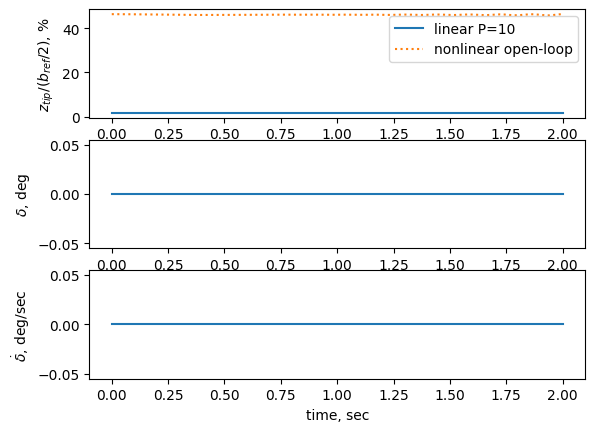

In [35]:
#control_surface_input = np.loadtxt(os.path.join(output_folder, pazy_model_closed.case_name, "pazy_udp_closed_loop_gust_response_control_input"))
#delta_dot = np.diff(np.rad2deg(control_surface_input))/pazy_model_closed.dt
#tip_displacement_nonlinear_P10 = np.loadtxt(os.path.join(output_folder, pazy_model_closed.case_name, "pazy_udp_closed_loop_gust_response_sensor_measurement"))
#time_array_nonlinear_closed_loop = np.arange(0, len(tip_displacement_nonlinear_P10) * pazy_model_closed.dt, pazy_model_closed.dt)
#tip_displacement_nonlinear_P10 /= pazy_model_closed.b_ref/2
#tip_displacement_nonlinear_P10 *= 100

# Plot Data
fig, axs = plt.subplots(3, 1)
list_linestyles = ['-', '--', ':']
list_labels = ['linear P=10', 'nonlinear P=10', 'nonlinear open-loop']
axs[0].plot(time_array_linear, normalised_tip_deflection_linear[:,1], list_linestyles[0], label=list_labels[0])
#axs[0].plot(time_array_nonlinear_closed_loop,
#            tip_displacement_nonlinear_P10,
#            list_linestyles[1],
#            label=list_labels[1])
axs[0].plot(time_array, normalised_tip_displacement, list_linestyles[-1], label=list_labels[-1])

axs[0].legend()
axs[0].set(ylabel='$z_{tip}/(b_{ref}/2)$, %')


axs[1].plot(time_array_linear, control_surface_deflection_deg[:,1], list_linestyles[0])
#axs[1].plot(time_array_nonlinear_closed_loop, np.rad2deg(control_surface_input), list_linestyles[1])

axs[1].set(ylabel='$\delta$, deg')

axs[2].plot(time_array_linear, control_surface_deflection_rate_deg[:,0], list_linestyles[0])
#axs[2].plot(time_array_nonlinear_closed_loop[1:],
#            delta_dot,
#            list_linestyles[1])

axs[2].set(ylabel='$\dot{\delta}$, deg/sec')
for ax in axs.flat:
    ax.set(xlabel='time, sec')